# ROC-AUC Comparison for All 8 Models

This notebook loads all 8 trained models and plots ROC curves in one figure:
- Random Forest
- Logistic Regression
- SVM
- KNN
- XGBoost
- CNN
- LSTM
- MLP

In [1]:
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# Path resolution
candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
models_dir = None
dataset_path = None
for root in candidate_roots:
    m = root / 'models'
    d1 = root.parent / 'Synthetic_Data' / 'synthetic_foot_ulcer_dataset_RISK.csv'
    d2 = root / 'Synthetic_Data' / 'synthetic_foot_ulcer_dataset_RISK.csv'
    if m.exists() and (d1.exists() or d2.exists()):
        models_dir = m
        dataset_path = d1 if d1.exists() else d2
        break

if models_dir is None:
    models_dir = Path('../models').resolve()
    dataset_path = Path('../../Synthetic_Data/synthetic_foot_ulcer_dataset_RISK.csv').resolve()

output_dir = Path.cwd()
output_dir.mkdir(exist_ok=True, parents=True)

print(f'Models dir: {models_dir.resolve()}')
print(f'Dataset:    {dataset_path.resolve()}')
print(f'Output dir: {output_dir.resolve()}')

# Dataset prep
df = pd.read_csv(dataset_path)
y_all = df['label'].values.astype(int)

TEMP_FEATURES = ['temp_heel', 'temp_ball', 'temp_arch', 'temp_toe']
PRESSURE_FEATURES = ['press_heel', 'press_ball', 'press_arch', 'press_toe']
VITAL_FEATURES = ['spo2', 'heartRate']
ACTIVITY_FEATURES = ['stepCount']
ENGINEERED_FEATURES = ['max_pressure', 'pressure_variance', 'max_temp', 'temp_variance']

RAW_19_FEATURES = [
    'temp_heel', 'press_heel', 'temp_ball', 'press_ball',
    'temp_arch', 'press_arch', 'temp_toe', 'press_toe',
    'spo2', 'heartRate', 'acc_x', 'acc_y', 'acc_z',
    'gyro_x', 'gyro_y', 'gyro_z', 'stepCount', 'batteryLevel', 'risk_score'
]
FEAT_15 = TEMP_FEATURES + PRESSURE_FEATURES + VITAL_FEATURES + ACTIVITY_FEATURES + ENGINEERED_FEATURES

df_proc = df.copy()
df_proc['max_pressure'] = df_proc[PRESSURE_FEATURES].max(axis=1)
df_proc['pressure_variance'] = df_proc[PRESSURE_FEATURES].var(axis=1)
df_proc['max_temp'] = df_proc[TEMP_FEATURES].max(axis=1)
df_proc['temp_variance'] = df_proc[TEMP_FEATURES].var(axis=1)

print(f'Rows: {len(df_proc)}')

Models dir: E:\S4\WORKING\neurosocks-ai\ML\models
Dataset:    E:\S4\WORKING\neurosocks-ai\Synthetic_Data\synthetic_foot_ulcer_dataset_RISK.csv
Output dir: E:\S4\WORKING\neurosocks-ai\ML\ROC_AUC
Rows: 10000


In [2]:
def resolve_existing_path(*candidates):
    for c in candidates:
        p = Path(c)
        if p.exists():
            return p
    raise FileNotFoundError(f'None of these paths exist: {candidates}')

class CompatibleLSTM(tf.keras.layers.LSTM):
    def __init__(self, *args, **kwargs):
        kwargs.pop('time_major', None)
        super().__init__(*args, **kwargs)

def load_keras_model_robust(primary_path, extra_candidates=None):
    import shutil
    candidates = [Path(primary_path)]
    if extra_candidates:
        candidates.extend([Path(p) for p in extra_candidates])

    custom_objects = {'LSTM': CompatibleLSTM}
    errors = []
    for p in candidates:
        if not p.exists():
            continue
        try:
            return tf.keras.models.load_model(p, compile=False, custom_objects=custom_objects)
        except Exception as e:
            errors.append(f'{p}: {e}')
            if p.suffix == '.keras':
                try:
                    import h5py
                    if h5py.is_hdf5(str(p)):
                        temp_h5 = p.with_suffix('.autofix_load.h5')
                        shutil.copy2(p, temp_h5)
                        try:
                            model = tf.keras.models.load_model(temp_h5, compile=False, custom_objects=custom_objects)
                            return model
                        finally:
                            if temp_h5.exists():
                                temp_h5.unlink(missing_ok=True)
                except Exception as h5e:
                    errors.append(f'{p} (hdf5 fallback): {h5e}')

    raise RuntimeError('Failed to load keras model. Details:\n' + '\n'.join(errors))

def pick_feature_matrix(expected_n_features):
    if expected_n_features == len(FEAT_15):
        return df_proc[FEAT_15].values.astype(np.float32), FEAT_15
    if expected_n_features == len(RAW_19_FEATURES):
        return df_proc[RAW_19_FEATURES].values.astype(np.float32), RAW_19_FEATURES
    cols = [c for c in df_proc.columns if c != 'label'][:expected_n_features]
    return df_proc[cols].values.astype(np.float32), cols

def load_scaler_or_fit(candidates, X):
    for c in candidates:
        p = Path(c)
        if p.exists():
            sc = joblib.load(p)
            if hasattr(sc, 'n_features_in_') and int(sc.n_features_in_) == X.shape[1]:
                return sc, p
    sc = StandardScaler().fit(X)
    return sc, None

def make_lstm_sequences(X_scaled, y, seq_len):
    X_seq = np.array([X_scaled[i:i+seq_len] for i in range(len(X_scaled) - seq_len + 1)], dtype=np.float32)
    y_seq = y[seq_len - 1:]
    return X_seq, y_seq

In [3]:
# Resolve model paths
rf_path = resolve_existing_path(models_dir / 'random_forest_model.pkl')
lr_path = resolve_existing_path(models_dir / 'LR' / 'logistic_regression_model.pkl')
svm_path = resolve_existing_path(models_dir / 'svm_model.pkl')
knn_path = resolve_existing_path(models_dir / 'KNN' / 'knn_model.pkl')
xgb_path = resolve_existing_path(models_dir / 'XG_Boost' / 'xgboost_model.pkl', models_dir / 'XG_Boost' / 'xgboost_model.json')
cnn_path = resolve_existing_path(models_dir / 'cnn_model.keras', models_dir / 'cnn_model.h5')
lstm_path = resolve_existing_path(models_dir / 'LSTM' / 'lstm_model.keras')
mlp_path = resolve_existing_path(models_dir / 'MLP' / 'mlp_model.keras')

models = {
    'Random Forest': {'kind': 'sklearn', 'model': joblib.load(rf_path), 'scalers': [models_dir / 'scaler.pkl']},
    'Logistic Regression': {'kind': 'sklearn', 'model': joblib.load(lr_path), 'scalers': [models_dir / 'LR' / 'scaler.pkl']},
    'SVM': {'kind': 'sklearn', 'model': joblib.load(svm_path), 'scalers': [models_dir / 'scaler.pkl']},
    'KNN': {'kind': 'sklearn', 'model': joblib.load(knn_path), 'scalers': [models_dir / 'KNN' / 'scaler.pkl']},
    'XGBoost': {'kind': 'sklearn', 'model': joblib.load(xgb_path) if xgb_path.suffix == '.pkl' else None, 'scalers': [models_dir / 'XG_Boost' / 'scaler.pkl']},
    'CNN': {'kind': 'keras_cnn', 'model': load_keras_model_robust(cnn_path, [models_dir / 'cnn_model.h5', models_dir / 'cnn_model.keras']), 'scalers': [models_dir / 'cnn_scaler.pkl']},
    'LSTM': {'kind': 'keras_lstm', 'model': load_keras_model_robust(lstm_path, [models_dir / 'LSTM' / 'lstm_model.keras']), 'scalers': [models_dir / 'LSTM' / 'scaler.pkl']},
    'MLP': {'kind': 'keras_mlp', 'model': load_keras_model_robust(mlp_path, [models_dir / 'MLP' / 'mlp_model.keras']), 'scalers': [models_dir / 'MLP' / 'scaler.pkl']},
}

if models['XGBoost']['model'] is None:
    import xgboost as xgb
    xgb_model = xgb.XGBClassifier()
    xgb_model.load_model(str(xgb_path))
    models['XGBoost']['model'] = xgb_model

print('Loaded models successfully.')

Loaded models successfully.


In [4]:
# ROC-AUC computation for all 8 models
roc_data = []

for name, info in models.items():
    model = info['model']
    kind = info['kind']

    if kind == 'sklearn':
        n_feat = int(getattr(model, 'n_features_in_', 15))
    elif kind == 'keras_cnn':
        n_feat = int(model.input_shape[1])
    elif kind == 'keras_lstm':
        n_feat = int(model.input_shape[2])
    else:
        n_feat = int(model.input_shape[1])

    X_raw, used_cols = pick_feature_matrix(n_feat)
    scaler, scaler_path = load_scaler_or_fit(info['scalers'], X_raw)
    X_scaled = scaler.transform(X_raw).astype(np.float32)

    if kind == 'keras_cnn':
        X_in = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)
        y_true = y_all
        y_score = model.predict(X_in, verbose=0).ravel()
    elif kind == 'keras_lstm':
        seq_len = int(model.input_shape[1])
        X_seq, y_seq = make_lstm_sequences(X_scaled, y_all, seq_len)
        y_true = y_seq
        y_score = model.predict(X_seq, verbose=0).ravel()
    elif kind == 'keras_mlp':
        y_true = y_all
        y_score = model.predict(X_scaled, verbose=0).ravel()
    else:
        y_true = y_all
        if hasattr(model, 'predict_proba'):
            y_score = model.predict_proba(X_scaled)[:, 1]
        else:
            y_score = model.decision_function(X_scaled)

    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc_val = roc_auc_score(y_true, y_score)

    roc_data.append({
        'model': name,
        'fpr': fpr,
        'tpr': tpr,
        'auc': auc_val,
        'n_features': n_feat,
        'scaler': str(scaler_path) if scaler_path is not None else 'fallback(StandardScaler fit on current data)'
    })

auc_df = pd.DataFrame([{
    'Model': d['model'],
    'ROC_AUC': d['auc'],
    'Features_Used': d['n_features'],
    'Scaler_Used': d['scaler']
} for d in roc_data]).sort_values('ROC_AUC', ascending=False)

print('ROC-AUC calculated for all 8 models')
display(auc_df)

ROC-AUC calculated for all 8 models


,Model,ROC_AUC,Features_Used,Scaler_Used
2,SVM,0.999193,19,fallback(StandardScaler fit on current data)
5,CNN,0.998186,19,e:\S4\WORKING\neurosocks-ai\ML\models\cnn_scal...
4,XGBoost,0.995446,15,e:\S4\WORKING\neurosocks-ai\ML\models\XG_Boost...
3,KNN,0.995024,15,e:\S4\WORKING\neurosocks-ai\ML\models\KNN\scal...
0,Random Forest,0.993882,15,fallback(StandardScaler fit on current data)
7,MLP,0.988098,15,e:\S4\WORKING\neurosocks-ai\ML\models\MLP\scal...
1,Logistic Regression,0.976273,15,e:\S4\WORKING\neurosocks-ai\ML\models\LR\scale...
6,LSTM,0.484082,15,e:\S4\WORKING\neurosocks-ai\ML\models\LSTM\sca...


Plot saved: E:\S4\WORKING\neurosocks-ai\ML\ROC_AUC\all_8_models_roc_auc_plot.png
AUC table saved: E:\S4\WORKING\neurosocks-ai\ML\ROC_AUC\all_8_models_roc_auc_scores.csv


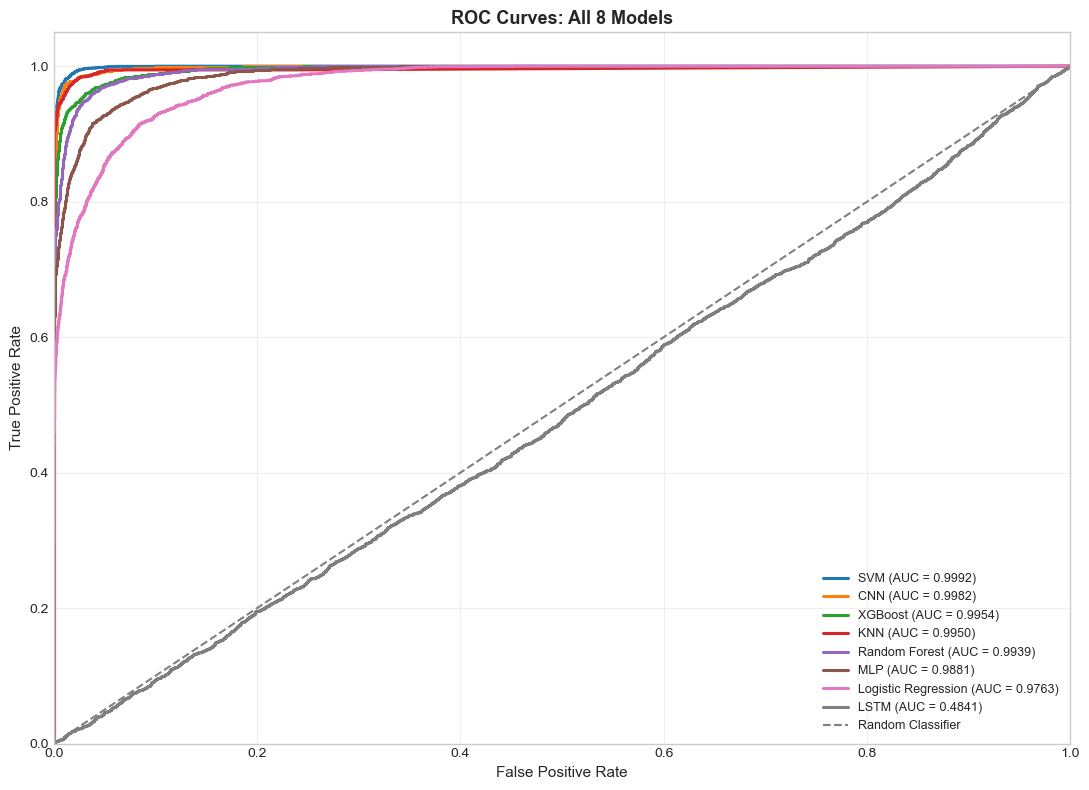

In [5]:
# Plot and save ROC curves
fig, ax = plt.subplots(figsize=(11, 8))

palette = sns.color_palette('tab10', len(roc_data))
for i, d in enumerate(sorted(roc_data, key=lambda x: x['auc'], reverse=True)):
    ax.plot(d['fpr'], d['tpr'], lw=2.2, color=palette[i % len(palette)],
            label=f"{d['model']} (AUC = {d['auc']:.4f})")

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', lw=1.5, label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves: All 8 Models', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()

plot_path = output_dir / 'all_8_models_roc_auc_plot.png'
auc_csv_path = output_dir / 'all_8_models_roc_auc_scores.csv'

plt.savefig(plot_path, dpi=300, bbox_inches='tight')
auc_df.to_csv(auc_csv_path, index=False)

print(f'Plot saved: {plot_path.resolve()}')
print(f'AUC table saved: {auc_csv_path.resolve()}')
plt.show()